In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)


## 1. Load the data

In [2]:
df = pd.read_csv("data/telco_churn.csv")
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### How many customers churn overall?

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


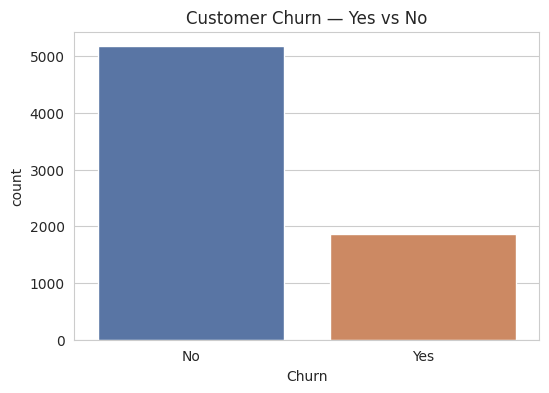

In [3]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

sns.countplot(x="Churn", data=df, hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False)
plt.title("Customer Churn — Yes vs No")
plt.show()


**In plain words:** about 1 in 4 customers churns. That's an imbalanced dataset (more "No" than "Yes"), which is worth mentioning if asked — it means accuracy alone won't tell the full story, so we also look at the confusion matrix later.

## 2. Clean the data

`customerID` is just an ID, not useful for prediction, so we drop it. `TotalCharges` is stored as text and has a handful of blank values (new customers with 0 months of billing) — we convert it to a number and drop those few rows.

In [4]:
df = df.drop(columns=["customerID"])

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows with missing TotalCharges:", df["TotalCharges"].isna().sum())

df = df.dropna(subset=["TotalCharges"])
print("Shape after cleaning:", df.shape)


Rows with missing TotalCharges: 11
Shape after cleaning: (7032, 20)


## 3. Turn categories into numbers

Models can't read text like `"Yes"` or `"Month-to-month"` directly, so every categorical (text) column is converted into 0/1 columns with `pd.get_dummies` — e.g. `Contract` becomes three columns: `Contract_One year`, `Contract_Two year`, `Contract_Month-to-month`, each either 0 or 1.

In [5]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.shape)
df_encoded.head()


(7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 4. A quick look before modeling: does contract type matter?

Before building any model, it's worth checking one obvious business hypothesis: do customers on flexible, month-to-month contracts churn more than customers locked into a 1- or 2-year plan?

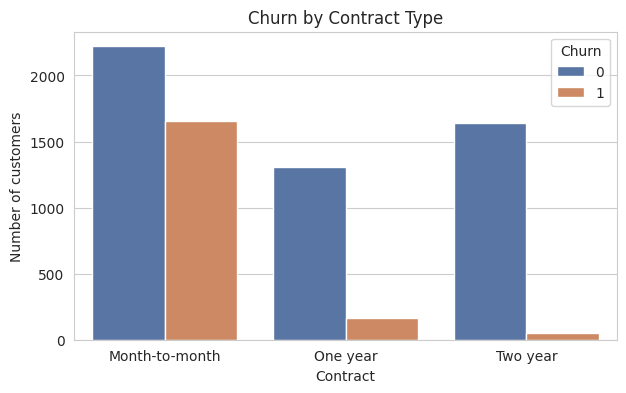

In [6]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Contract", hue="Churn", palette=["#4C72B0", "#DD8452"])
plt.title("Churn by Contract Type")
plt.ylabel("Number of customers")
plt.show()


**Observation:** month-to-month customers churn far more often than customers on 1- or 2-year contracts. This is the single most intuitive driver in the dataset — a good story to lead with in an interview, since it needs no modeling knowledge to understand: customers with less commitment leave more easily.

## 5. Split into training and test data

In [7]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {X_train.shape[0]}, Test rows: {X_test.shape[0]}")


Training rows: 5625, Test rows: 1407


**Why split the data:** we train the model on 80% of customers and test it on the other 20% it has never seen — this checks whether it actually learned a general pattern, rather than just memorizing the training customers.

## 6. Train two models and compare them

We keep this simple on purpose: one straightforward linear model (Logistic Regression) and one rule-based model (Decision Tree) — no advanced tuning, so both are easy to explain in plain language.

- **Logistic Regression:** finds a weighted combination of features that best separates churners from non-churners.
- **Decision Tree:** learns a series of yes/no questions (like "Is tenure < 12 months? Is Contract Month-to-month?") to arrive at a prediction — closer to how a human would reason through it manually.

In [8]:
log_reg = LogisticRegression(max_iter=3000)
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_test)

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, log_reg_pred):.3f}")
print(f"Decision Tree accuracy:       {accuracy_score(y_test, tree_pred):.3f}")


Logistic Regression accuracy: 0.805
Decision Tree accuracy:       0.778


*(Note: `Decision Tree` is capped at `max_depth=5` — a shallow tree on purpose, so it stays simple and doesn't just memorize the training data.)*

## 7. A closer look at the better model

Accuracy alone can be misleading with imbalanced data (remember: ~1 in 4 customers churns, so a model that just guesses "No" every time would already be ~74% accurate but useless). The confusion matrix shows exactly what the model gets right and wrong for *each* class.

Best model: Logistic Regression


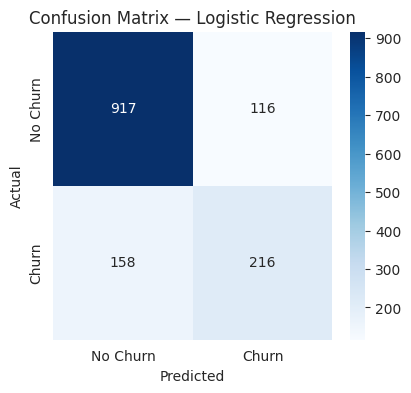

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.58      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [9]:
best_pred = log_reg_pred if accuracy_score(y_test, log_reg_pred) >= accuracy_score(y_test, tree_pred) else tree_pred
best_name = "Logistic Regression" if accuracy_score(y_test, log_reg_pred) >= accuracy_score(y_test, tree_pred) else "Decision Tree"
print(f"Best model: {best_name}")

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

print(classification_report(y_test, best_pred, target_names=["No Churn", "Churn"]))


**How to read the confusion matrix in one sentence:** the top-left and bottom-right boxes are correct predictions; the top-right and bottom-left are mistakes. In a churn use case, the bottom-left box (actual churners the model missed) is the costly mistake — those are customers the business could have tried to retain but didn't know to.

## 8. What factors matter most?

Logistic Regression gives each feature a coefficient — a positive coefficient means that feature pushes the prediction toward "churn," a negative one pushes toward "stays."


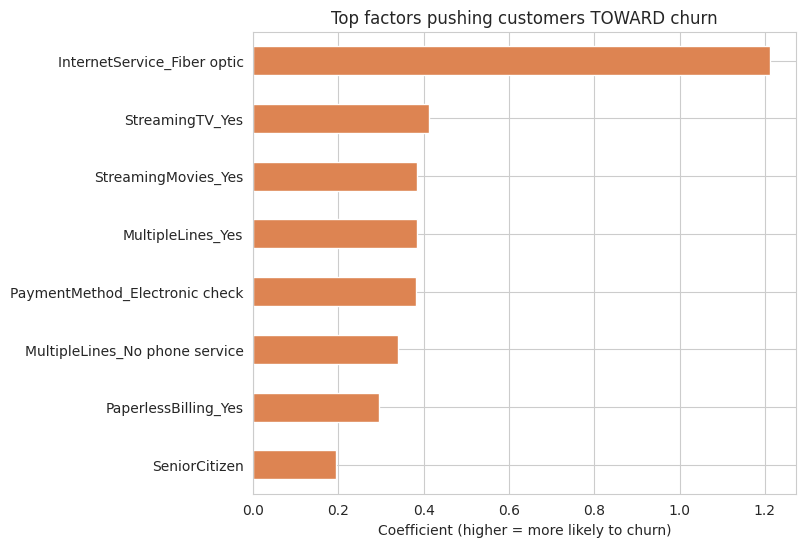

In [10]:
coefficients = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(7, 6))
coefficients.tail(8).plot(kind="barh", color="#DD8452")
plt.title("Top factors pushing customers TOWARD churn")
plt.xlabel("Coefficient (higher = more likely to churn)")
plt.show()
